In [1]:
import colorsys
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

sys.path.append("../src/utils/")
import bosperrus
import visium_hd
import seaborn as sns
from border_fit import ALL_SAMPLES, FIT_PALETTE, MIN_COMPONENT_SPOTS, get_grid_components, get_or_compute_component_fit, native_pixel_size_um

/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [20]:
# One hue family per technology (kept clear of fit_palette's green/magenta/
# yellow/blue; validated with the dataviz skill's validate_palette.py), 4
# lightness steps per family so individual samples stay distinguishable.
# dataset_type itself is redundantly encoded by marker shape.
DATASET_TYPE_MARKERS = {"visium_demo": "o", "visium_custom": "s", "stomics_custom": "^"}
_TECH_HUES = {"visium_demo": 100 / 360, "visium_custom": 195 / 360, "stomics_custom": 280 / 360}
_TECH_SAT = {"visium_demo": 0.48, "visium_custom": 0.62, "stomics_custom": 0.55}
_TECH_LIGHTNESS_RANGE = {"visium_demo": (0.2, 0.8), "visium_custom": (0.2, 0.8), "stomics_custom": (0.2, 0.8)}


def build_sample_palette(all_samples):
    palette = {}
    for dtype, group in all_samples.groupby("dataset_type", sort=False):
        names = group["name"].tolist()
        lo, hi = _TECH_LIGHTNESS_RANGE[dtype]
        for i, name in enumerate(names):
            l = lo + (hi - lo) * i / max(len(names) - 1, 1)
            r, g, b = colorsys.hls_to_rgb(_TECH_HUES[dtype], l, _TECH_SAT[dtype])
            palette[name] = '#{:02x}{:02x}{:02x}'.format(round(r * 255), round(g * 255), round(b * 255))
    return palette


sample_palette = build_sample_palette(ALL_SAMPLES)

In [3]:
results = list()

In [4]:
for i, sample in enumerate(ALL_SAMPLES["name"].values):
    loader_type = ALL_SAMPLES["loader"].iloc[i]
    h5ad_path = ALL_SAMPLES["h5ad_path"].iloc[i]
    bin_size_um = ALL_SAMPLES["bin_size_um"].iloc[i]

    n_counts, array_row, array_col, _ = visium_hd.load_counts_and_coords(loader_type, h5ad_path)
    components = get_grid_components(array_row, array_col)
    print(f"{sample}: {len(components)} component(s) > {MIN_COMPONENT_SPOTS} spots")

    for component_rank, member_mask, component_size in components:
        fit = get_or_compute_component_fit(
            sample, component_rank, component_size, h5ad_path, bin_size_um,
            array_row[member_mask], array_col[member_mask], n_counts[member_mask],
        )
        results.append([
            sample, component_rank, f"{sample}_{component_rank}", component_size,
            fit["blade_thresh"], fit["bsp_thresh"], fit["blade_thresh_corrected"],
            bin_size_um, fit["blade_thresh_um"], fit["bsp_thresh_um"], fit["blade_thresh_corrected_um"],
        ])

breast_cancer: 3 component(s) > 1000 spots
pancreas: 1 component(s) > 1000 spots
colon_cancer_ff: 1 component(s) > 1000 spots
breast_cancer_tma: 36 component(s) > 1000 spots
Pat1: 1 component(s) > 1000 spots
Pat2: 3 component(s) > 1000 spots
Pat3: 4 component(s) > 1000 spots
Pat4: 2 component(s) > 1000 spots
A02991D1: 1 component(s) > 1000 spots
A02994C6: 5 component(s) > 1000 spots
Y01087DD: 5 component(s) > 1000 spots
Y01084J8: 4 component(s) > 1000 spots


In [5]:
results_df = pd.DataFrame(results, columns=[
    "sample", "component_rank", "component_label", "component_size",
    "blade_thresh", "bsp_thresh", "blade_thresh_corrected",
    "bin_size_um", "blade_thresh_um", "bsp_thresh_um", "blade_thresh_corrected_um",
])
results_df = results_df.merge(ALL_SAMPLES[["name", "dataset_type"]], left_on="sample", right_on="name")
counts = results_df["sample"].value_counts()
results_df["num_components"] = results_df["sample"].apply(lambda x: counts[x])
results_df["1/num_components"] = 1/results_df["num_components"]

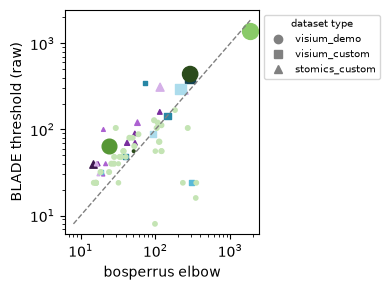

In [21]:
# Figure 1: bosperrus elbow vs. BLADE (raw) -- one point per connected
# component; marker = dataset_type, color = sample (see technology_palette
# cell for how sample_palette is built).
fig, ax = plt.subplots(figsize=(4, 3))
for dtype, group in results_df.groupby("dataset_type"):
    marker = DATASET_TYPE_MARKERS[dtype]
    for sample, sample_group in group.groupby("sample"):
        ax.scatter(sample_group["bsp_thresh_um"], sample_group["blade_thresh_um"],
                   marker=marker, color=sample_palette[sample], s=1/10*np.sqrt(sample_group["component_size"]))
lims = [results_df[["bsp_thresh_um", "blade_thresh_um"]].min().min(), results_df[["bsp_thresh_um", "blade_thresh_um"]].max().max()]
ax.plot(lims, lims, color="gray", ls="--", lw=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("bosperrus elbow"); ax.set_ylabel("BLADE threshold (raw)")
marker_handles = [Line2D([0], [0], marker=m, color="gray", linestyle="", label=dt) for dt, m in DATASET_TYPE_MARKERS.items()]
ax.legend(handles=marker_handles, fontsize=7, title="dataset type", title_fontsize=7, bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

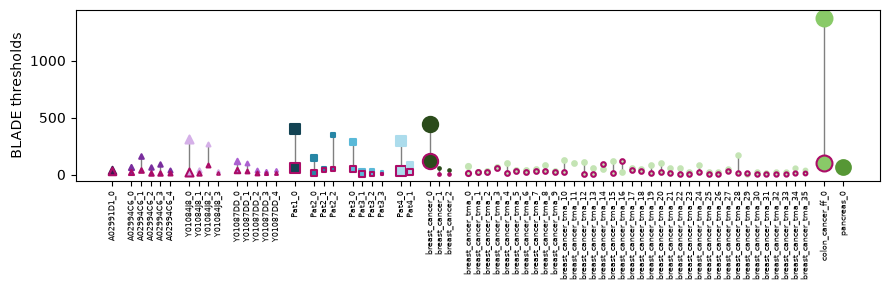

In [45]:
# Figure 2: BLADE raw vs. corrected, one x position per connected component;
# marker = dataset_type, fill = sample, ring = raw (gray) vs. corrected
# (fit_palette's Exponential Saturation Fit color).

fig, ax = plt.subplots(figsize=(9, 3))

# Sort components in the desired order
plot_df = results_df.sort_values(["dataset_type", "sample", "component_rank"]).reset_index(drop=True)

# Horizontal positions: fixed spacing within samples, additional gap between samples
component_spacing = 1
sample_gap = 2

x_pos = []
x = 0
previous_sample = None

for _, row in plot_df.iterrows():
    if previous_sample is not None:
        x += sample_gap if row["sample"] != previous_sample else component_spacing
    x_pos.append(x)
    previous_sample = row["sample"]

x_pos = np.array(x_pos)

for i, row in plot_df.iterrows():
    x = x_pos[i]
    color = sample_palette[row["sample"]]
    marker = DATASET_TYPE_MARKERS[row["dataset_type"]]

    # Connecting line: raw -> corrected
    ax.plot([x, x], [row["blade_thresh_um"], row["blade_thresh_corrected_um"]], color="gray", linewidth=1, zorder=0)

    # Raw BLADE threshold
    ax.scatter(x, row["blade_thresh_um"], marker=marker, color=color, edgecolors=color, linewidth=1.5, zorder=2, s=1 / 10 * np.sqrt(row["component_size"]))

    # Corrected BLADE threshold
    ax.scatter(x, row["blade_thresh_corrected_um"], marker=marker, color=color, edgecolors=FIT_PALETTE["Exponential Saturation Fit"], linewidth=1.5, zorder=2, s=1 / 10 * np.sqrt(row["component_size"]))

# X-axis ticks at the component positions
ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df["component_label"], rotation=90, fontsize=6)

ax.set_ylabel("BLADE thresholds")

#plt.yscale("log")
plt.tight_layout()
plt.show()

In [44]:
# Exp-sat fit of total counts vs. distance OUTSIDE the image-derived tissue
# mask, per connected component (same components Figures 1/2 use). This fit
# runs in native pixel space, not grid steps -- native pixel size is NOT
# fixed across samples (confirmed: two Visium scans measured 0.27 vs.
# 0.18 um/px), so b/d_outside_max are also reported in um via
# native_pixel_size_um, empirically measured from the known grid pitch.
mask_diffusion_results = []
for i, sample in enumerate(ALL_SAMPLES["name"].values):
    loader_type = ALL_SAMPLES["loader"].iloc[i]
    h5ad_path = ALL_SAMPLES["h5ad_path"].iloc[i]
    dataset_type = ALL_SAMPLES["dataset_type"].iloc[i]
    bin_size_um = ALL_SAMPLES["bin_size_um"].iloc[i]

    n_counts, array_row, array_col, spatial = visium_hd.load_counts_and_coords(loader_type, h5ad_path)
    pixel_size_um = native_pixel_size_um(array_row, array_col, spatial, bin_size_um)
    mask, pixel_scale = visium_hd.load_image_mask(loader_type, h5ad_path, sample)
    coords_rc_mask_space = np.stack([spatial[:, 1] * pixel_scale, spatial[:, 0] * pixel_scale], axis=1)
    dist_mask_space = bosperrus.distance_to_mask(coords_rc_mask_space, mask).to_numpy()

    for component_rank, member_mask, component_size in get_grid_components(array_row, array_col):
        outside_mask = (dist_mask_space > 0) & member_mask
        d_outside = dist_mask_space[outside_mask] / pixel_scale
        exp_sat_fit = bosperrus.ExponentialSaturationFit(n_counts[outside_mask], d_outside)
        exp_sat_fit.fit()

        result = {
            "sample": sample, "component_rank": component_rank,
            "component_label": f"{sample}_{component_rank}", "dataset_type": dataset_type,
            "component_size": component_size, "pixel_size_um": pixel_size_um,
            "n_outside": int(outside_mask.sum()),
            "frac_outside": float(outside_mask.sum() / component_size),
            "d_outside_max": float(d_outside.max()) if len(d_outside) else None,
            "converged": bool(exp_sat_fit._converged), "AIC": exp_sat_fit.AIC,
        }
        if exp_sat_fit._converged:
            result.update({
                "a": exp_sat_fit.params["exponential_saturation_a"],
                "b": exp_sat_fit.params["exponential_saturation_b"],
                "b_um": exp_sat_fit.params["exponential_saturation_b"] / pixel_size_um,
                "c": exp_sat_fit.params["exponential_saturation_c"],
                "observed_effect_strength": exp_sat_fit.observed_effect_strength,
            })
        mask_diffusion_results.append(result)

mask_diffusion_df = pd.DataFrame(mask_diffusion_results)
mask_diffusion_df

KeyboardInterrupt: 

In [ ]:
# Plot 3: each sample's fitted exp-sat curve(s), shape-normalized and
# anchored to their own observed_effect_strength (y(0) = effect_strength,
# y(d_max) = 0 -- same convention as src/figure3/plot_metrics.py's main
# panel) -- one small panel per sample, one line per connected component,
# colored with the same sample_palette as Figures 1/2.
_EPS = 1e-10

samples_order = ALL_SAMPLES.sort_values(["dataset_type", "name"])["name"].tolist()
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 1.6 * n_rows), sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, sample in zip(axes, samples_order):
    color = sample_palette[sample]
    sample_df = mask_diffusion_df[mask_diffusion_df["sample"] == sample]
    for _, row in sample_df.iterrows():
        if not row["converged"]:
            continue
        d_grid = np.linspace(0, row["d_outside_max"], 60)
        S = bosperrus.ExponentialSaturationFit.exp_sat(d_grid, row["a"], row["b"], row["c"])
        c_near, c_far = S[0], S[-1]
        shape = (S - c_far) / (c_near - c_far + _EPS)
        y = shape * row["observed_effect_strength"]
        ax.plot(d_grid, y, color=color, alpha=0.8, lw=1.2)
    ax.set_title(sample, fontsize=7)

for ax in axes[len(samples_order):]:
    ax.axis("off")

fig.supxlabel("distance outside image tissue mask (native px)", fontsize=8)
fig.supylabel("shape-normalized total counts", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
mask_diffusion_df["alpha"] = mask_diffusion_df["observed_effect_strength"]  # (c_border-c_center)/(c_border+c_center) -- scale-invariant, unlike raw a (confounded by bin size/depth)
mask_diffusion_df["beta"] = mask_diffusion_df["b_um"]  # 1/um, not 1/native-px -- native pixel size isn't comparable across samples/scans (see native_pixel_size_um)

In [ ]:
mask_diffusion_df["1/beta"] = 1 / mask_diffusion_df["beta"] 

In [ ]:
counts = mask_diffusion_df["sample"].value_counts()
mask_diffusion_df["num_components"] = mask_diffusion_df["sample"].apply(lambda x: counts[x])
mask_diffusion_df["1/num_components"] = 1/mask_diffusion_df["num_components"]

In [ ]:
mask_diffusion_df.iloc[39]

In [ ]:
mask_diffusion_df

In [ ]:
sns.scatterplot(mask_diffusion_df.drop(39), y="observed_effect_strength", x="1/beta", style="dataset_type", hue="sample", size="1/num_components", palette=sample_palette, markers=DATASET_TYPE_MARKERS)